In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from prophet import Prophet

# Load the three files
df1 = pd.read_csv('api_data_aadhar_enrolment_0_500000.csv')
df2 = pd.read_csv('api_data_aadhar_enrolment_500000_1000000.csv')
df3 = pd.read_csv('api_data_aadhar_enrolment_1000000_1006029.csv')

# Concatenate into one DataFrame
df = pd.concat([df1, df2, df3], ignore_index=True)

# Parse date (DD-MM-YYYY format)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Clean state names (remove asterisks or extras)
df['state'] = df['state'].str.replace(r'\*', '', regex=True).str.strip()

# Add total enrolment column
df['total_enrol'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

# Add month/year for grouping
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year  # All 2025, but useful for future

# Quick check: Shape should be ~ (1006029, 10)
print(df.shape)
print(df.head())
print(df.describe())  # Stats summary
print(df.isnull().sum())  # Should be no nulls

(1006029, 10)
        date          state          district  pincode  age_0_5  age_5_17  \
0 2025-03-02      Meghalaya  East Khasi Hills   793121       11        61   
1 2025-03-09      Karnataka   Bengaluru Urban   560043       14        33   
2 2025-03-09  Uttar Pradesh      Kanpur Nagar   208001       29        82   
3 2025-03-09  Uttar Pradesh           Aligarh   202133       62        29   
4 2025-03-09      Karnataka   Bengaluru Urban   560016       14        16   

   age_18_greater  total_enrol  month  year  
0              37          109      3  2025  
1              39           86      3  2025  
2              12          123      3  2025  
3              15          106      3  2025  
4              21           51      3  2025  
                                date       pincode       age_0_5  \
count                        1006029  1.006029e+06  1.006029e+06   
mean   2025-10-23 18:26:44.387150336  5.186415e+05  3.525709e+00   
min              2025-03-02 00:00:00  1.000

In [ ]:
# Drop duplicates if any (unlikely)
df = df.drop_duplicates()

# Filter out rows with zero enrolments (optional, to focus on active data)
df_active = df[df['total_enrol'] > 0]

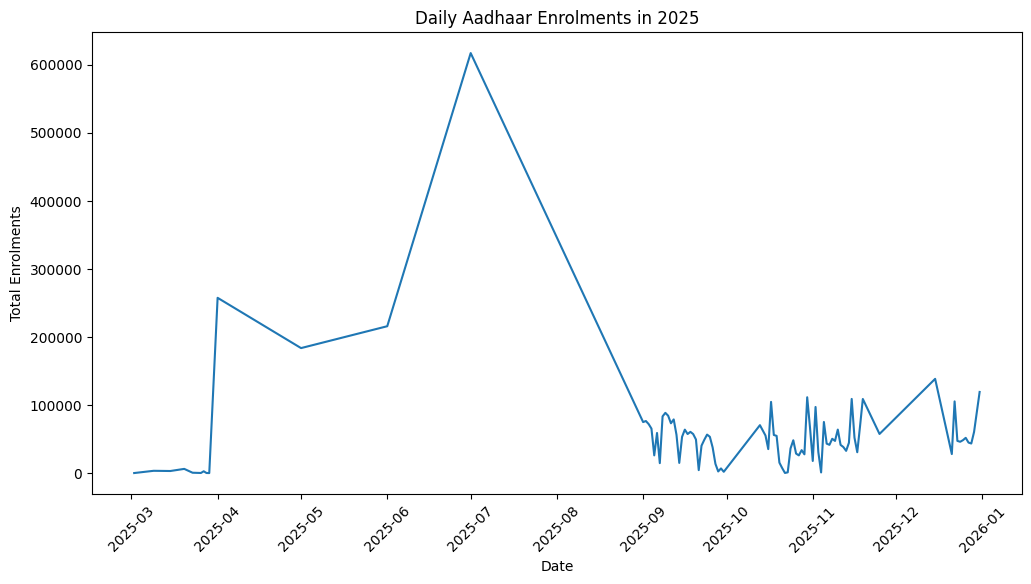

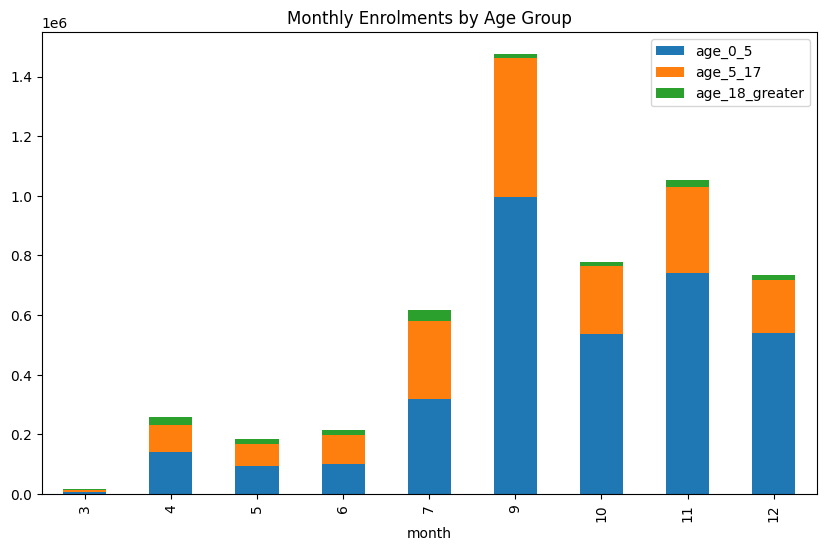

In [ ]:
# Daily total enrolments
daily_trends = df.groupby('date')['total_enrol'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=daily_trends, x='date', y='total_enrol')
plt.title('Daily Aadhaar Enrolments in 2025')
plt.xlabel('Date')
plt.ylabel('Total Enrolments')
plt.xticks(rotation=45)
plt.show()

# Monthly by age group
monthly_age = df.groupby('month')[['age_0_5', 'age_5_17', 'age_18_greater']].sum()
monthly_age.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Monthly Enrolments by Age Group')
plt.show()

# Export aggregates for Power BI
daily_trends.to_csv('daily_trends.csv', index=False)
monthly_age.to_csv('monthly_age.csv', index=False)

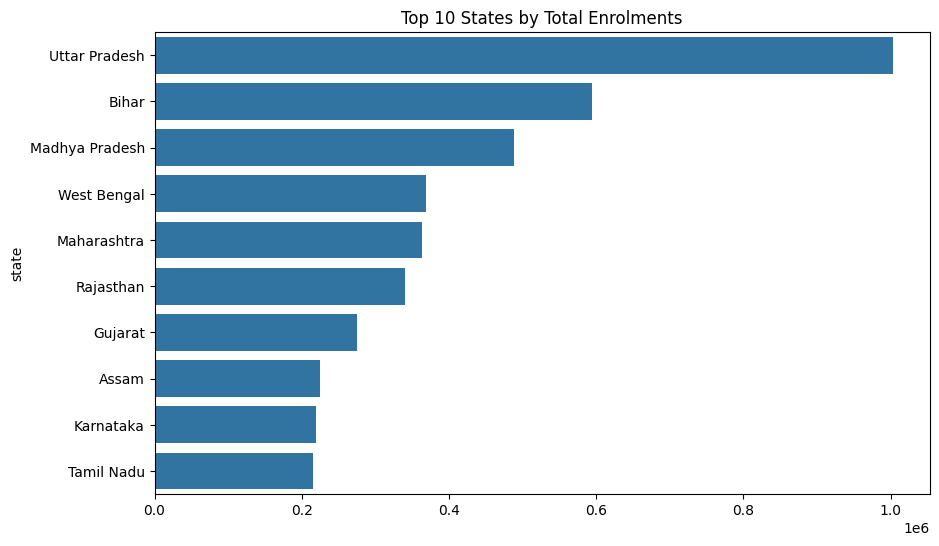

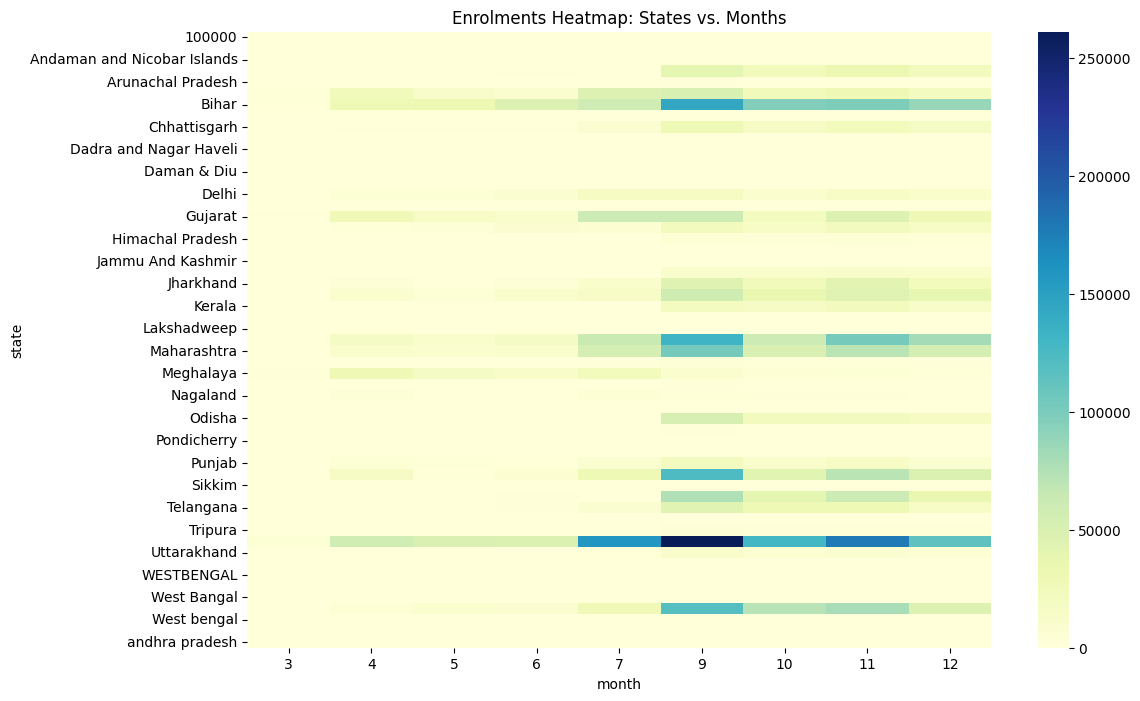

In [ ]:
# Top 10 states by total enrolments
state_enrol = df.groupby('state')['total_enrol'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=state_enrol.values, y=state_enrol.index)
plt.title('Top 10 States by Total Enrolments')
plt.show()

# Heatmap: Enrolments by state and month (pivot table)
state_month_pivot = df.pivot_table(index='state', columns='month', values='total_enrol', aggfunc='sum', fill_value=0)
plt.figure(figsize=(12,8))
sns.heatmap(state_month_pivot, cmap='YlGnBu')
plt.title('Enrolments Heatmap: States vs. Months')
plt.show()

# Export for Power BI
state_enrol.to_csv('state_enrol.csv')
state_month_pivot.to_csv('state_month_pivot.csv')

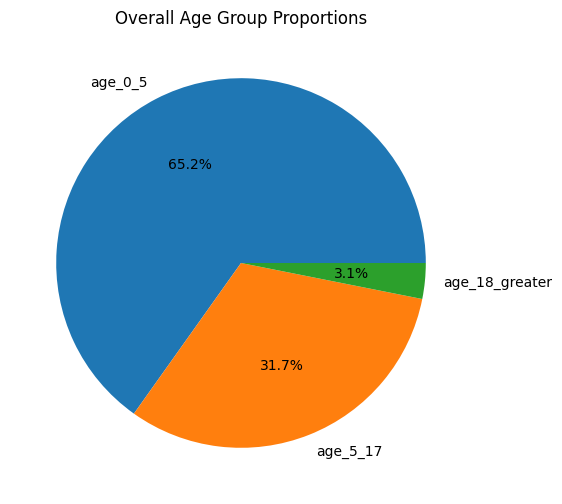

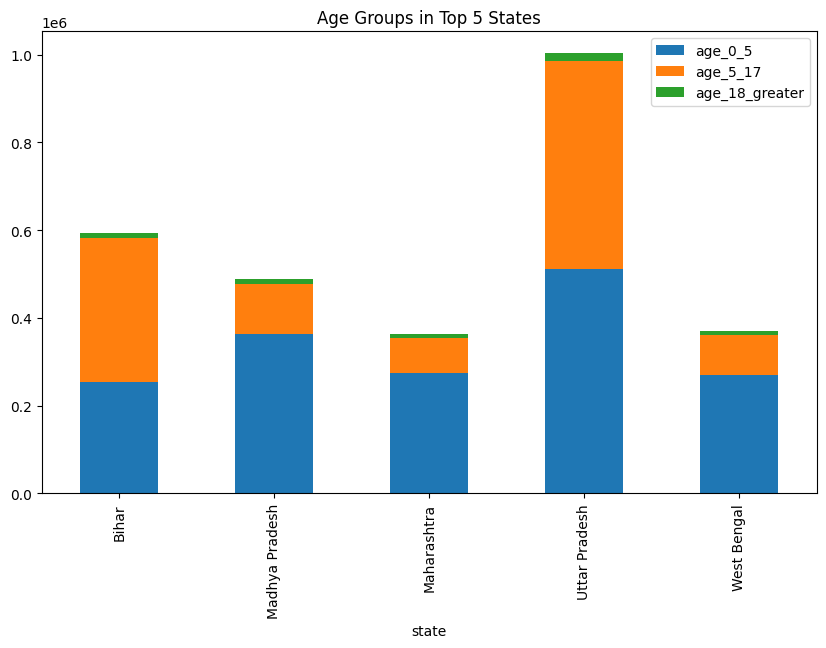

In [ ]:
# Age proportions overall
age_totals = df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()
age_totals.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Overall Age Group Proportions')
plt.show()

# By state (top 5)
top_states = df.groupby('state')['total_enrol'].sum().nlargest(5).index
age_by_state = df[df['state'].isin(top_states)].groupby('state')[['age_0_5', 'age_5_17', 'age_18_greater']].sum()
age_by_state.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Age Groups in Top 5 States')
plt.show()

# Export
age_by_state.to_csv('age_by_state.csv')

        date          state          district  pincode  age_0_5  age_5_17  \
0 2025-03-02      Meghalaya  East Khasi Hills   793121       11        61   
1 2025-03-09      Karnataka   Bengaluru Urban   560043       14        33   
2 2025-03-09  Uttar Pradesh      Kanpur Nagar   208001       29        82   
3 2025-03-09  Uttar Pradesh           Aligarh   202133       62        29   
4 2025-03-09      Karnataka   Bengaluru Urban   560016       14        16   
5 2025-03-09          Bihar         Sitamarhi   843331       20        49   
6 2025-03-09          Bihar         Sitamarhi   843330       23        24   
7 2025-03-09  Uttar Pradesh          Bahraich   271865       26        60   
8 2025-03-09  Uttar Pradesh         Firozabad   283204       28        26   
9 2025-03-09          Bihar   Purbi Champaran   845418       30        48   

   age_18_greater  total_enrol  month  year  anomaly  
0              37          109      3  2025       -1  
1              39           86      3  202

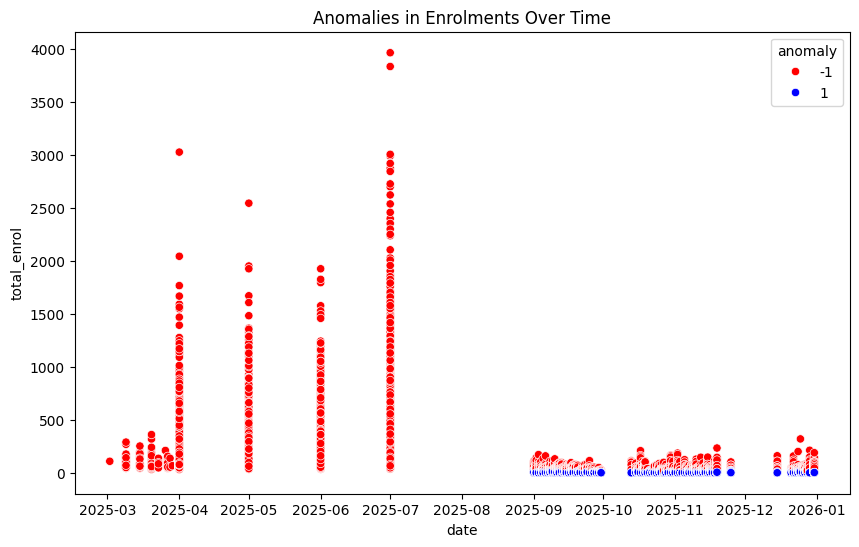

In [ ]:
# Features for model (focus on totals and ages)
features = df[['total_enrol', 'age_0_5', 'age_5_17', 'age_18_greater']]

# Fit model
iso = IsolationForest(contamination=0.05, random_state=42)  # 5% anomalies
df['anomaly'] = iso.fit_predict(features)

# Anomalies (where -1)
anomalies = df[df['anomaly'] == -1]
print(anomalies.head(10))  # View top anomalies

# Visualize (e.g., scatter plot)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='date', y='total_enrol', hue='anomaly', palette={1:'blue', -1:'red'})
plt.title('Anomalies in Enrolments Over Time')
plt.show()

# Export anomalies for Power BI
anomalies.to_csv('anomalies.csv', index=False)

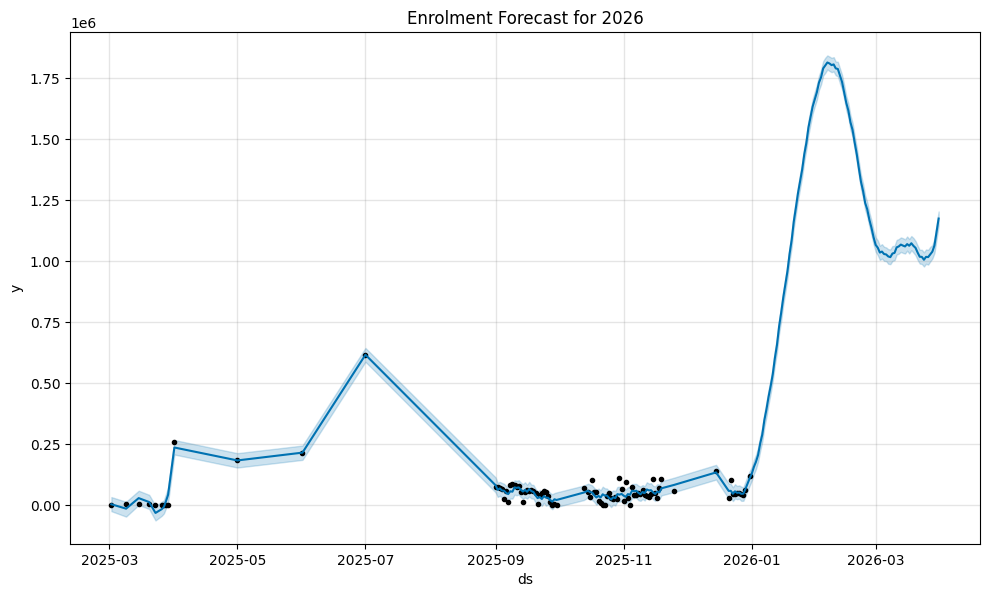

In [ ]:
# Prepare time-series data
ts = df.groupby('date')['total_enrol'].sum().reset_index().rename(columns={'date':'ds', 'total_enrol':'y'})

# Fit Prophet
m = Prophet(yearly_seasonality=True, daily_seasonality=False)  # Adjust based on data
m.fit(ts)

# Forecast next 90 days (Q1 2026)
future = m.make_future_dataframe(periods=90)
forecast = m.predict(future)

# Plot
m.plot(forecast)
plt.title('Enrolment Forecast for 2026')
plt.show()

# Export forecast for Power BI
forecast.to_csv('forecast.csv', index=False)